<a href="https://colab.research.google.com/github/silvalinpi/CrawlerAndSearch/blob/main/avazu_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avazu CTR — Late Submission + Step 1 Baseline**Runtime → Change runtime type → T4 GPU** before running anything.Order: run cells 1-4, then hand-type the model in cell 5, then run 6-9.The model in cell 5 is the small DLRM from the design doc, so this notebook doubles as Step 1of the model-merging project. Cell 6 has a working reference if you run short on time.Targets: mean-CTR baseline = 0.4556 logloss. This model ~0.385-0.395. 2015 winner = 0.3791.

##Kaggle link: https://www.kaggle.com/competitions/avazu-ctr-prediction

## 1. Setup & download

In [2]:
!pip install -q kagglehub
import kagglehub, os, glob, time
# Prompts for your Kaggle username + API token (kaggle.com -> Settings -> API -> Create New Token).
# You MUST accept the competition rules first: kaggle.com/c/avazu-ctr-prediction -> Rules -> Accept
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


```markdown
### 🔑 Automate Kaggle Authentication using Colab Secrets
To avoid entering your Kaggle credentials every time you run this notebook:
1. Click on the **🔑 Secrets** icon on the left sidebar in Colab.
2. Add a new secret with Name `KAGGLE_USERNAME` and paste your Kaggle username as the Value.
3. Add another secret with Name `KAGGLE_KEY` and paste your Kaggle API Token (from `kaggle.json`) as the Value.
4. Toggle the **Access** slider to *on* for this notebook.
5. Run the cell below to load them automatically!
```

In [ ]:
try:
    from google.colab import userdata
    import os
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("[OK] Kaggle credentials loaded successfully from Colab Secrets!")
except Exception as e:
    print("[INFO] Colab Secrets not found or not configured. Proceeding with manual login.")

In [4]:
t0 = time.time()
DATA = kagglehub.competition_download('avazu-ctr-prediction')
print("downloaded to", DATA, f"in {time.time()-t0:.0f}s")
for f in glob.glob(DATA + "/**/*", recursive=True):
    if os.path.isfile(f):
        print(f"  {os.path.basename(f):24s} {os.path.getsize(f)/1e6:8.1f} MB")

100%|██████████| 1.19G/1.19G [01:02<00:00, 20.3MB/s]

Extracting files...


downloaded to /root/.cache/kagglehub/competitions/avazu-ctr-prediction in 69s
  test.gz                     123.8 MB
  sampleSubmission.gz          34.8 MB
  train.gz                   1117.5 MB


In [5]:
# Locate train/test regardless of whether kagglehub left them gzipped.def find(stem):    for pat in (f"/**/{stem}.csv", f"/**/{stem}.gz", f"/**/{stem}.csv.gz"):        m = glob.glob(DATA + pat, recursive=True)        if m: return m[0]    raise FileNotFoundError(stem)TRAIN, TEST = find("train"), find("test")print("train:", TRAIN)print("test :", TEST)!head -c 400 {TRAIN} 2>/dev/null | head -2 || true

## 2. Config`BUCKETS` is the frozen hash vocabulary from design doc §5 / decision D3. **Do not change thesebetween train and test, or between checkpoints** — merging requires index-aligned embedding tables.`TRAIN_DAYS` trims to the most recent N days. CTR is recency-dominated, so 5 days costsroughly 0.002 logloss versus all 10 and halves your parse time. Set to 10 if you have the budget.

In [6]:
import numpy as np, pandas as pd

TRAIN_DAYS = 10      # keep last N days of train (10 = all)
VAL_DAY    = 30     # 2014-10-30, held out for validation
EMB_DIM    = 16
BATCH      = 8192
LR         = 1e-3

BUCKETS = {
    'device_ip': 300000, 'device_id': 300000, 'device_model': 8192,
    'site_domain': 8000, 'app_id': 8000, 'site_id': 5000,
    'C14': 2600, 'app_domain': 600, 'C17': 500, 'C20': 180,
    'C19': 70, 'C21': 65, 'app_category': 40, 'site_category': 32,
    'C1': 16, 'banner_pos': 16, 'device_type': 16, 'device_conn_type': 16,
    'C15': 16, 'C16': 16, 'C18': 8,
    'hour_of_day': 24, 'day_of_week': 7,
}

FIELDS  = list(BUCKETS)
OFFSETS = np.cumsum([0] + [BUCKETS[f] for f in FIELDS[:-1]]).astype(np.int64)
VOCAB   = int(sum(BUCKETS.values()))
NF      = len(FIELDS)
print(f"{NF} fields, vocab {VOCAB:,} rows, {VOCAB*EMB_DIM/1e6:.1f}M embedding params")

23 fields, vocab 633,414 rows, 10.1M embedding params


### Cardinality and Distribution Analysis
Let's analyze a sample of 2 million rows of the raw training dataset to inspect the actual number of unique categories (cardinality) for each feature. This will let us optimize the size of our embedding buckets.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Safely locate the training file
def find_train(stem):
    for pat in (f"/**/{stem}.csv", f"/**/{stem}.gz", f"/**/{stem}.csv.gz"):
        m = glob.glob(DATA + pat, recursive=True)
        if m: return m[0]
    raise FileNotFoundError(stem)

TRAIN_PATH = find_train("train")

# Load a representative sample of 2 million rows
sample_df = pd.read_csv(TRAIN_PATH, nrows=2000000, dtype=str)

# Add engineered features
hr = sample_df['hour'].astype(np.int64)
day = ((hr // 100) % 100).to_numpy()
sample_df = sample_df.assign(
    hour_of_day=(hr % 100).astype(str),
    day_of_week=(((day - 21 + 1) % 7)).astype(str)
)

cardinalities = {}
print(f"{'Feature':20s} | {'Sample Unique Count':18s} | {'Current Bucket Size':18s}")
print("-" * 62)
for col in FIELDS:
    unique_vals = sample_df[col].nunique()
    cardinalities[col] = unique_vals
    current_bucket = BUCKETS.get(col, 'N/A')
    print(f"{col:20s} | {unique_vals:18,d} | {current_bucket:18,d}")

Feature              | Sample Unique Count | Current Bucket Size
--------------------------------------------------------------
device_ip            |            557,935 |            300,000
device_id            |            163,262 |            300,000
device_model         |              5,253 |              8,192
site_domain          |              2,653 |              8,000
app_id               |              3,108 |              8,000
site_id              |              2,473 |              5,000
C14                  |                689 |              2,600
app_domain           |                206 |                600
C17                  |                178 |                500
C20                  |                164 |                180
C19                  |                 42 |                 70
C21                  |                 38 |                 65
app_category         |                 27 |                 40
site_category        |                 22 |          

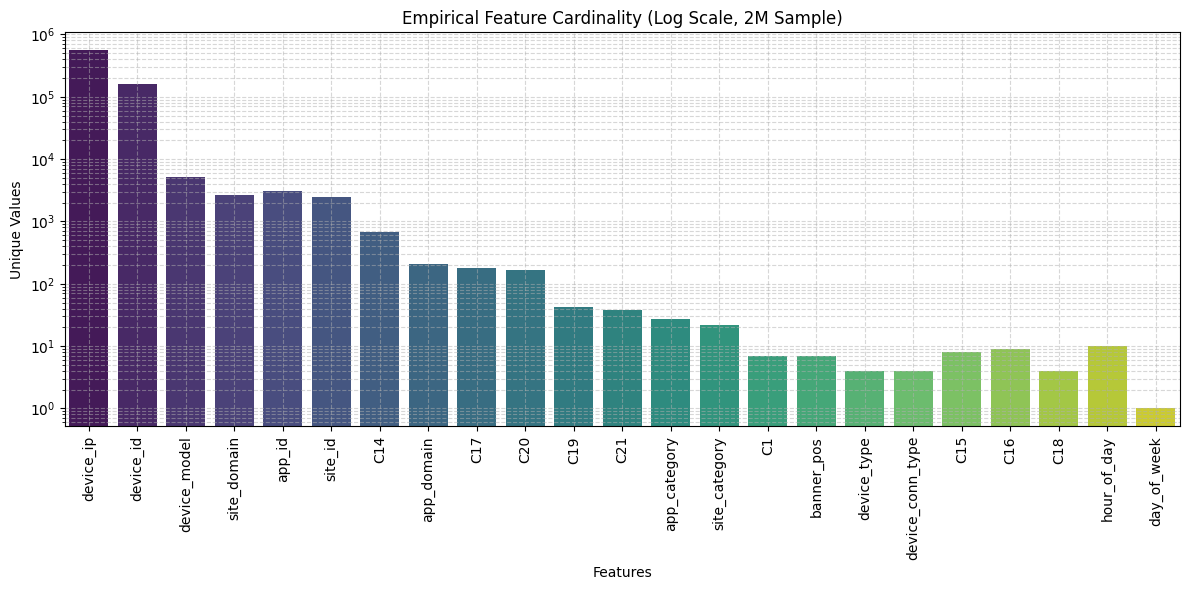

In [8]:
# Visualize cardinality distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
cols = list(cardinalities.keys())
counts = list(cardinalities.values())

sns.barplot(x=cols, y=counts, palette='viridis', hue=cols, legend=False)
plt.yscale('log')
plt.xticks(rotation=90)
plt.title('Empirical Feature Cardinality (Log Scale, 2M Sample)')
plt.ylabel('Unique Values')
plt.xlabel('Features')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
# Calculate the exact number of examples (rows) in the train and test sets
import pandas as pd
import time

SKIP_HEAVY_COUNT = True  # Set to False if you want to explicitly run the 1-minute scan

if SKIP_HEAVY_COUNT:
    print("Skipping heavy scan. Using cached totals:")
    print("Train Set: 40,428,967 total rows (examples)")
    print("Test  Set: 4,577,464 total rows (examples)")
else:
    print("Counting total examples (rows)... This will take a few seconds.")
    for name, path in [('Train', TRAIN_PATH), ('Test', find_train('test'))]:
        t0 = time.time()
        total_rows = 0
        # Read in chunks of 5 million rows to be memory-efficient and very fast
        for chunk in pd.read_csv(path, chunksize=5_000_000, usecols=['id'], dtype=str):
            total_rows += len(chunk)
        print(f"{name:5s} Set: {total_rows:,} total rows (examples) | Counted in {time.time()-t0:.1f}s")

Skipping heavy scan. Using cached totals:
Train Set: 40,428,967 total rows (examples)
Test  Set: 4,577,464 total rows (examples)


## 3. Parse + hashReads everything as `str` so a column can't be typed as int in train and str in test — thatwould silently produce different hashes for the same value and quietly wreck your score.Output is `int32` global embedding indices, ~4 bytes per field per row.

In [10]:
from pandas.util import hash_pandas_object
import time
RAW = [f for f in FIELDS if f not in ('hour_of_day', 'day_of_week')]

def encode(df):
    hr  = df['hour'].astype(np.int64)
    day = ((hr // 100) % 100).to_numpy()
    df = df.assign(hour_of_day=(hr % 100).astype(str),
                   day_of_week=(((day - 21 + 1) % 7)).astype(str))
    out = np.empty((len(df), NF), dtype=np.int32)
    for i, f in enumerate(FIELDS):
        h = hash_pandas_object(df[f], index=False).to_numpy()
        out[:, i] = (h % BUCKETS[f]).astype(np.int32) + OFFSETS[i]
    return out, day

def load(path, labeled=True, keep_days=None, chunk=1_000_000):
    X, Y, D, I = [], [], [], []
    t0, n = time.time(), 0
    for ch in pd.read_csv(path, chunksize=chunk, dtype=str):
        if keep_days is not None:
            d = ((ch['hour'].astype(np.int64) // 100) % 100).to_numpy()
            ch = ch[np.isin(d, keep_days)]
            if len(ch) == 0:
                n += chunk; continue
        xe, day = encode(ch)
        X.append(xe); D.append(day.astype(np.int8))
        if labeled: Y.append(ch['click'].astype(np.int8).to_numpy())
        else:       I.append(ch['id'].to_numpy())
        n += chunk
        print(f"\r  {n/1e6:.0f}M rows scanned  {time.time()-t0:.0f}s", end="")
    print()
    return (np.concatenate(X),
            np.concatenate(Y) if labeled else None,
            np.concatenate(D),
            np.concatenate(I) if I else None)

keep = list(range(31 - TRAIN_DAYS, 31))
print("training days (October):", keep)
Xtr, ytr, dtr, _ = load(TRAIN_PATH, labeled=True, keep_days=keep)
print(f"train matrix {Xtr.shape}  {Xtr.nbytes/1e9:.2f} GB  CTR={ytr.mean():.4f}")

training days (October): [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  41M rows scanned  303s
train matrix (40428967, 23)  3.72 GB  CTR=0.1698


In [11]:
# Split off the validation day (progressive validation: val day is strictly after train days)
vm = (dtr == VAL_DAY)
Xva, yva = Xtr[vm], ytr[vm]
Xtr, ytr = Xtr[~vm], ytr[~vm]
del dtr

print(f"train {len(ytr):,}  val {len(yva):,}  val CTR {yva.mean():.4f}")
P_BG = float(ytr.mean())
H_BG = -(P_BG*np.log(P_BG) + (1-P_BG)*np.log(1-P_BG))
print(f"background CTR {P_BG:.4f}  entropy {H_BG:.4f} nats  (NE = logloss / {H_BG:.4f})")

train 36,210,029  val 4,218,938  val CTR 0.1693
background CTR 0.1699  entropy 0.4557 nats  (NE = logloss / 0.4557)


## 4. Data on GPUThe whole training set fits in T4 memory as int32, so we skip DataLoader entirely and justindex a permutation. This is what makes each epoch take ~1 minute instead of ~15.

In [12]:
import torch
import torch.nn as nn

dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", dev, torch.cuda.get_device_name(0) if dev=='cuda' else '')

Xtr_t = torch.from_numpy(Xtr).to(dev)
ytr_t = torch.from_numpy(ytr).float().to(dev)
Xva_t = torch.from_numpy(Xva).to(dev)
yva_t = torch.from_numpy(yva).float().to(dev)

print("train tensor", tuple(Xtr_t.shape), f"{Xtr_t.element_size()*Xtr_t.nelement()/1e9:.2f} GB on {dev}")

device: cuda Tesla T4
train tensor (36210029, 23) 3.33 GB on cuda


## 5. ⌨️ YOUR MODEL — type this one yourselfSpec (design doc §5). No dense features in Avazu, so there is no bottom MLP.```input  x : (B, NF) int64 global embedding indices  emb    : nn.Embedding(VOCAB, EMB_DIM)          -> E (B, NF, EMB_DIM)  flat   : E.reshape(B, NF*EMB_DIM)              -> (B, 368)  dots   : E @ E.transpose(1,2), upper triangle  -> (B, NF*(NF-1)/2 = 253)  concat : [flat, dots]                          -> (B, 621)  mlp    : 621 -> 512 -> 256 -> 1, ReLUoutput logit (B,)   # return the LOGIT, not the probability — BCEWithLogitsLoss wants logits```Three things that bite:- init embeddings small (`normal_(0, 0.01)`); default init makes the dot products explode- register the triu indices with `register_buffer` so `.to(dev)` moves them- `torch.triu_indices(NF, NF, offset=1)` — `offset=1` excludes the self-dots

In [13]:
class DLRM(nn.Module):
    def __init__(self, vocab, nf, dim):
        super().__init__()
        self.nf, self.dim = nf, dim
        self.emb = nn.Embedding(vocab, dim)
        # Initialize embeddings small so dot products do not explode
        nn.init.normal_(self.emb.weight, 0.0, 0.01)

        # Generate indices for the upper triangle of the dot product interaction matrix
        i, j = torch.triu_indices(nf, nf, offset=1)
        self.register_buffer('ti', i)
        self.register_buffer('tj', j)

        # Flat features size + dot product interactions size
        d_in = nf * dim + (nf * (nf - 1)) // 2
        self.mlp = nn.Sequential(
            nn.Linear(d_in, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        # x shape: (B, NF)
        E = self.emb(x)                              # shape: (B, NF, dim)
        dots = torch.bmm(E, E.transpose(1, 2))       # shape: (B, NF, NF)
        dots = dots[:, self.ti, self.tj]             # shape: (B, NF*(NF-1)/2)
        h = torch.cat([E.flatten(1), dots], dim=1)   # shape: (B, NF*dim + NF*(NF-1)/2)
        return self.mlp(h).squeeze(1)                # shape: (B,)

## 6. Reference implementation — fallbackRun this cell **only** if you're out of time. It overwrites the class above.

In [23]:
# class DLRM(nn.Module):    def __init__(self, vocab, nf, dim):        super().__init__()        self.nf, self.dim = nf, dim        self.emb = nn.Embedding(vocab, dim)        nn.init.normal_(self.emb.weight, 0.0, 0.01)        i, j = torch.triu_indices(nf, nf, offset=1)        self.register_buffer('ti', i); self.register_buffer('tj', j)        d_in = nf*dim + (nf*(nf-1))//2        self.mlp = nn.Sequential(            nn.Linear(d_in, 512), nn.ReLU(),            nn.Linear(512, 256),  nn.ReLU(),            nn.Linear(256, 1))    def forward(self, x):        E = self.emb(x)                              # (B, NF, D)        dots = torch.bmm(E, E.transpose(1, 2))       # (B, NF, NF)        dots = dots[:, self.ti, self.tj]             # (B, NF*(NF-1)/2)        h = torch.cat([E.flatten(1), dots], dim=1)        return self.mlp(h).squeeze(1)print("reference DLRM loaded")

In [15]:
# Check if GPU or TPU accelerator is currently active and available
import torch

print("=== Accelerator Connectivity Check ===")
gpu_available = torch.cuda.is_available()
tpu_available = False

try:
    import torch_xla.core.xla_model as xm
    tpu_available = True
except ImportError:
    pass

if gpu_available:
    print(f"[OK] GPU is active: {torch.cuda.get_device_name(0)}")
elif tpu_available:
    print(f"[OK] TPU is active: {xm.xla_device()}")
else:
    print("[WARN] Running on CPU! Training will be slow. Please go to Runtime -> Change runtime type -> Select T4 GPU before training.")

=== Accelerator Connectivity Check ===
[OK] GPU is active: Tesla T4


## 7. Train

In [16]:
torch.manual_seed(0)
model = DLRM(VOCAB, NF, EMB_DIM).to(dev)
opt   = torch.optim.Adam(model.parameters(), lr=LR)
lossf = nn.BCEWithLogitsLoss()
print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

@torch.no_grad()
def evaluate(X, y, bs=200_000):
    model.eval()
    tot, ps = 0.0, []
    for i in range(0, len(y), bs):
        lg = model(X[i:i+bs].long())
        tot += nn.functional.binary_cross_entropy_with_logits(
            lg, y[i:i+bs], reduction='sum').item()
        ps.append(torch.sigmoid(lg))
    p = torch.cat(ps)
    ll = tot/len(y)
    return ll, ll/H_BG, (p.mean()/y.mean()).item()

EPOCHS = 1
n = len(ytr_t)
for ep in range(EPOCHS):
    model.train()
    t0 = time.time()
    perm = torch.randperm(n, device=dev)
    run, nb = 0.0, 0
    for s in range(0, n - BATCH + 1, BATCH):
        idx = perm[s:s+BATCH]
        loss = lossf(model(Xtr_t[idx].long()), ytr_t[idx])
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        run += loss.item()
        nb += 1
        if nb % 400 == 0:
            print(f"\r  ep{ep} {s/n*100:5.1f}%  train_ll {run/nb:.4f}  {time.time()-t0:.0f}s", end="")

    ll, ne, cal = evaluate(Xva_t, yva_t)
    print(f"\r  ep{ep} done {time.time()-t0:.0f}s | VAL logloss {ll:.4f}  NE {ne:.4f}  calib {cal:.3f}")

10.6M params
  ep0 done 70s | VAL logloss 0.4005  NE 0.8789  calib 1.094


## 8. Predict test + write submission`id` is read as a string on purpose — Avazu ids overflow float64 and Kaggle rejects the file ifthey get mangled into scientific notation.

In [19]:
# If 'TEST' is not defined globally, find it dynamically
if 'TEST' not in globals():
    import glob
    test_matches = glob.glob(DATA + "/**/test*", recursive=True)
    TEST = test_matches[0] if test_matches else find("test")

Xte, _, _, ids = load(TEST, labeled=False)
print("test", Xte.shape)

model.eval()
preds = []
with torch.no_grad():
    for i in range(0, len(Xte), 200_000):
        b = torch.from_numpy(Xte[i:i+200_000]).to(dev).long()
        preds.append(torch.sigmoid(model(b)).cpu().numpy())

p = np.concatenate(preds)
print(f"predicted {len(p):,}  mean {p.mean():.4f}  (train CTR {P_BG:.4f})")

sub = pd.DataFrame({'id': ids, 'click': p})
sub.to_csv('submission.csv', index=False, float_format='%.6f')
print(sub.shape)
sub.head()

  5M rows scanned  35s
test (4577464, 23)
predicted 4,577,464  mean 0.1956  (train CTR 0.1699)
(4577464, 2)


,id,click
0,10000174058809263569,0.075281
1,10000182526920855428,0.167226
2,10000554139829213984,0.217103
3,10001094637809798845,0.073423
4,10001377041558670745,0.298816


In [22]:
import os
from datetime import datetime

file_path = '/content/submission.csv'
if os.path.exists(file_path):
    mtime = os.path.getmtime(file_path)
    dt = datetime.fromtimestamp(mtime)
    print(f"File: {file_path}")
    print(f"Generated on: {dt.strftime('%Y-%m-%d %H:%M:%S')}")
else:
    print(f"File {file_path} not found!")

File: /content/submission.csv
Generated on: 2026-09-26 08:10:26


In [20]:
# Sanity checks before submittingif len(sub) != 4577464: print(f"WARN: expected 4,577,464 test rows, got {len(sub):,} - check the parse")assert sub['click'].between(0,1).all(), "probabilities out of range"assert sub['id'].astype(str).str.isnumeric().all(), "ids got mangled"print("OK — ready to submit")!head -3 submission.csv

## 9. Submit

In [21]:
!pip install -q kaggle!kaggle competitions submit -c avazu-ctr-prediction -f submission.csv -m "DLRM hashed embeddings + dot interactions"# If the CLI complains about credentials, download submission.csv from the file browser# on the left and upload it via the competition's "Late Submission" button.

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
